In [1]:
import os
import torch
import matplotlib.pyplot as plt

from src.distributions.stars.ellipsoid.multimodal.data_enclosing import MultimodalDataEnclosingEllipsoidStarDistribution

from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism

from archetypes import AA

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean

# results folder
results_folder = os.path.join("results", "tree", "multi_ellipsoidal_star")
os.makedirs(results_folder, exist_ok=True)

# set random seed
torch.manual_seed(0)

Using NumPy backend


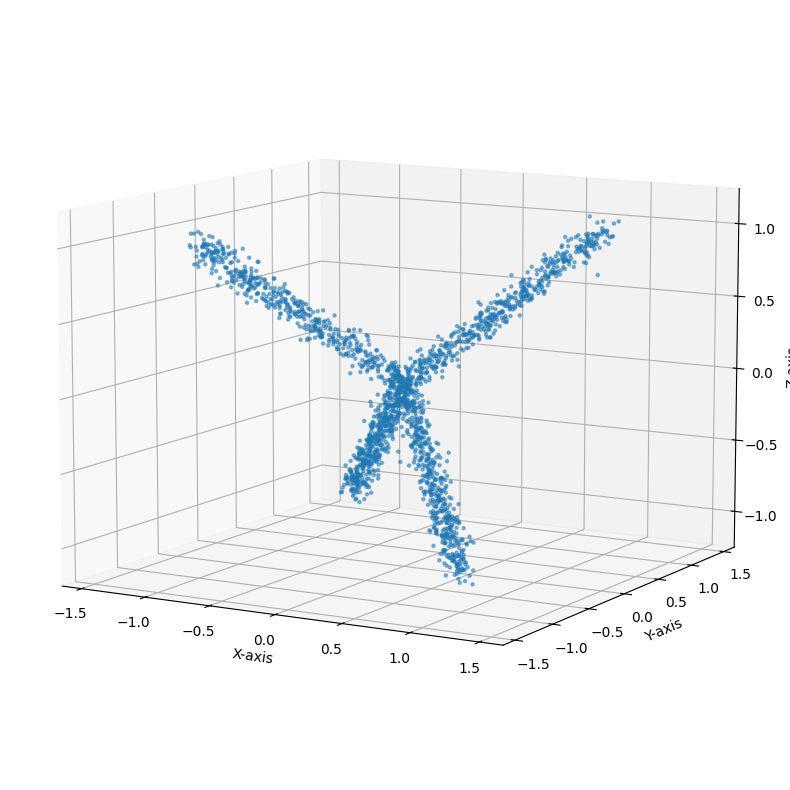

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

## Learn Star ##

In [ ]:
aa = AA(4, init='furthest_sum')
aa.fit(data)
labels = torch.unique(torch.tensor(aa.labels_))

# construct centers
centers = []
for label in labels:
    centers.append(data[torch.tensor(aa.labels_) == label].mean(dim=0))

archetypes = [archetype[None] for archetype in torch.from_numpy(aa.archetypes_).to(data.dtype)]

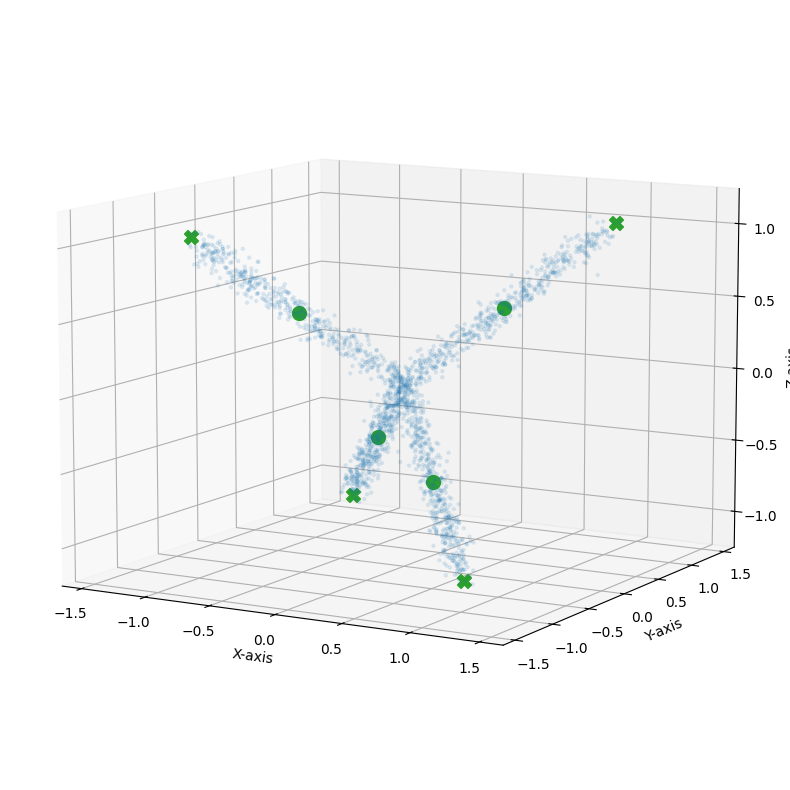

In [4]:
# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1)
for i in range(4):
    ax.scatter(archetypes[i][:, 0], archetypes[i][:, 1], archetypes[i][:, 2], s=100, color=plt.cm.tab10(2), marker='X', label='End Members')
    ax.scatter(centers[i][0], centers[i][1], centers[i][2], s=100, color=plt.cm.tab10(2), marker='o', label='Cluster Centers')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data+end_members.png"))
plt.show()

In [5]:
star = MultimodalDataEnclosingEllipsoidStarDistribution(archetypes, centers, reg_param=1e-2)

In [6]:
chi = StarVectorDiffeomorphism(3, star)
chi_manifold = StandardPullbackVectorEuclidean(chi)

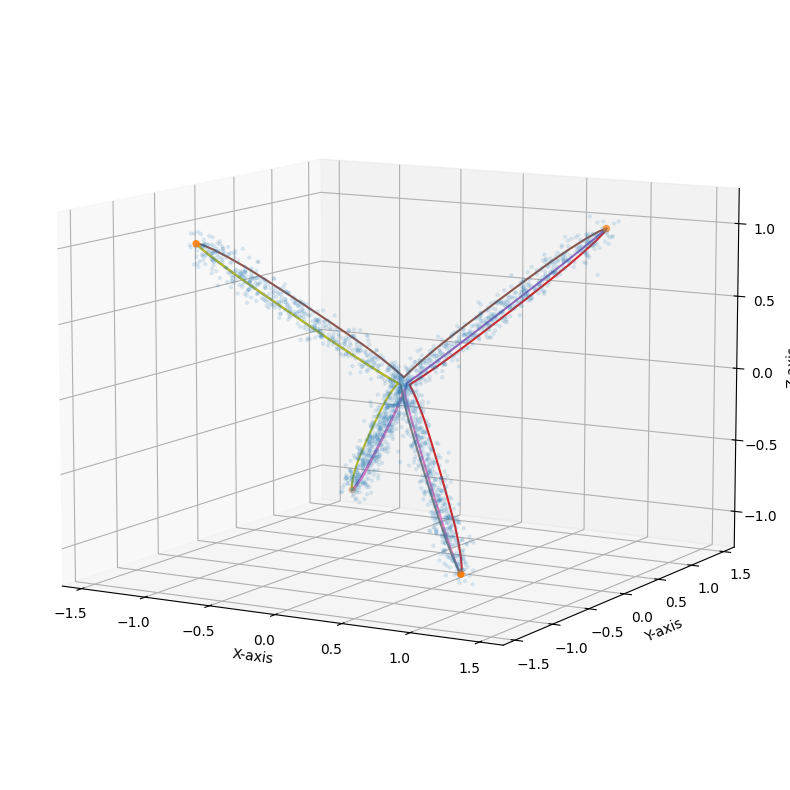

In [7]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    geodesics = chi_manifold.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
k = 3
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(geodesics[i, j, :, 0].numpy(), geodesics[i, j, :, 1].numpy(), geodesics[i, j, :, 2].numpy(), color=plt.cm.tab10(k), label=f'Geodesic {i}-{j}')
        k+=1
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()